In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras
print("Keras backend:", keras.backend.backend())

Keras backend: torch


In [2]:
import torch
torch.cuda.is_available()


True

In [3]:
import sys
print(sys.executable)

/home/bm/formation/deeplearning/deeplearning1/.venv/bin/python


In [4]:
import sklearn
# Imports the scikit-learn package itself.

print(sklearn.__version__)
# Shows the installed scikit-learn version.

1.9.1


In [5]:
%pip install scikit-learn
# Installs scikit-learn into the Python environment used by this notebook.

/home/bm/formation/deeplearning/deeplearning1/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
from keras.models import Sequential, Model
# Imports two ways of building neural networks with Keras:
# Sequential -> for a simple stack of layers, one after another.
# Model      -> for more flexible networks using the Functional API.


from keras.layers import Dense, Input, ReLU, Flatten, Dropout
# Imports several types of neural-network layers:
#
# Dense   -> fully connected layer: every neuron is connected to all outputs
#            from the previous layer.
#
# Input   -> defines the shape/type of data entering the neural network.
#
# ReLU    -> activation function: returns 0 for negative values
#            and keeps positive values unchanged.
#
# Flatten -> converts multidimensional data into a one-dimensional vector.
#            Example: a 28 x 28 image becomes 784 values.
#
# Dropout -> randomly disables some neurons during training.
#            This helps reduce overfitting.


# Pour calculer la loss (fonction de perte)
from keras.losses import SparseCategoricalCrossentropy
# Imports SparseCategoricalCrossentropy.
# It measures how wrong the model's predicted class probabilities are.
#
# "Sparse" means the real class labels are integers such as:
# 0, 1, 2, ... 9
# rather than one-hot encoded vectors.
#
# This is appropriate for MNIST because each image belongs to
# one digit class from 0 to 9.


from keras.metrics import Accuracy
# Imports the Accuracy metric.
# Accuracy measures the proportion of predictions that are correct.
#
# Example:
# 90 correct predictions out of 100 -> accuracy = 0.90 = 90%


# Gradient descent optimizer
from keras.optimizers import Adam
# Imports the Adam optimizer.
# The optimizer changes the neural network's weights during training
# in order to reduce the loss.
#
# Adam is an adaptive gradient-descent algorithm and is one of the
# most commonly used optimizers for neural networks.


from keras.datasets import fashion_mnist
# Imports the Fashion-MNIST dataset provided by Keras.
#
# Fashion-MNIST contains grayscale images of clothing items.
# Each image is 28 × 28 pixels, just like the original MNIST dataset.
#
# There are:
# - 60,000 training images
# - 10,000 test images
# - 10 different clothing classes


import numpy as np
# Imports NumPy and gives it the conventional alias `np`.
# NumPy is used for arrays, numerical calculations,
# shapes, statistics, transformations, etc.


import matplotlib.pyplot as plt
# Imports Matplotlib's plotting module as `plt`.
# It is used to create graphs and display images.
#
# For example:
# plt.imshow(image)
# displays an Fashion-MNIST image.


import seaborn as sns
# Imports Seaborn as `sns`.
# Seaborn is a visualization library built on top of Matplotlib.
# It is especially useful for statistical visualizations,
# such as heatmaps and confusion matrices.



from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
# Imports two evaluation tools from scikit-learn.
#
# confusion_matrix:
# Shows how the model's predictions are distributed across 
# the real classes.
# It helps us see WHICH classes are being confused with each other.
#
# Example:
# real class = 6
# predicted class = 0
#
# This is especially useful for Fashion-MNIST because some 
# clothing classes
# can look similar, such as Shirt, T-shirt, Pullover, and Coat.
#
#
# classification_report:
# Produces a summary table with several performance 
# measures for each class:
#
# precision
# recall
# f1-score
# support
#
# It gives much more information than accuracy alone.



In [7]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
# Loads the Fashion-MNIST dataset.
# x_train -> 60,000 training images
# y_train -> 60,000 corresponding labels
# x_test  -> 10,000 test images
# y_test  -> 10,000 corresponding labels


print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
# Displays the dimensions of the training images and labels.


print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")
# Displays the dimensions of the test images and labels.

x_train shape: (60000, 28, 28), y_train shape: (60000,)
x_test shape: (10000, 28, 28), y_test shape: (10000,)


In [8]:
np.random.seed(1)
np.random.seed(42)

In [9]:
train_test_split(x_train, y_train, test_size=0.2, random_state=1)


[array([[[  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         ...,
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0]],
 
        [[  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         ...,
         [  0,   0,  12, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0]],
 
        [[  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   3,   0],
         ...,
         [ 66, 112, 136, ...,  83, 170,  77],
         [  0,   0,   0, ..., 107, 105,  10],
         [  0,   0,   0, ...,   0,   0,   0]],
 
        ...,
 
        [[  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,

In [10]:
(x_train, x_val, y_train, y_val
) = train_test_split(x_train, y_train, test_size=0.2, random_state=1)
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_val shape: {x_val.shape}, y_val shape: {y_val.shape}")    

x_train shape: (48000, 28, 28), y_train shape: (48000,)
x_val shape: (12000, 28, 28), y_val shape: (12000,)


In [11]:
train_test_split(x_train, y_train, test_size=0.2)

[array([[[  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         ...,
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0]],
 
        [[  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         ...,
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0]],
 
        [[  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         ...,
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0]],
 
        ...,
 
        [[  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,

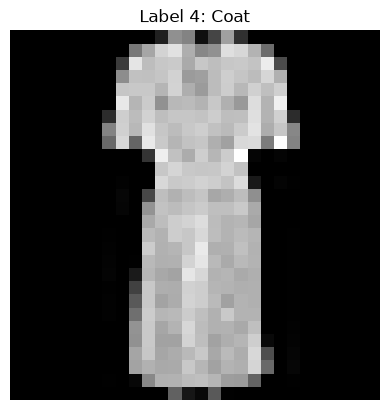

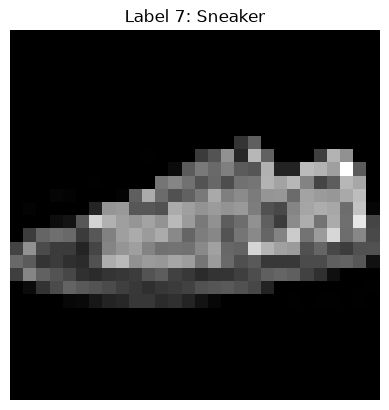

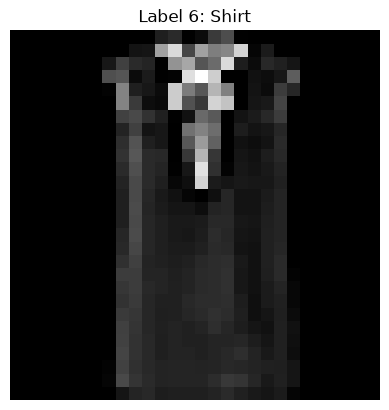

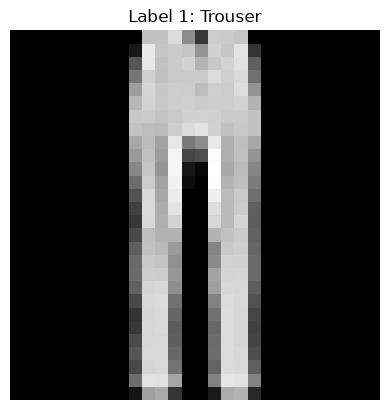

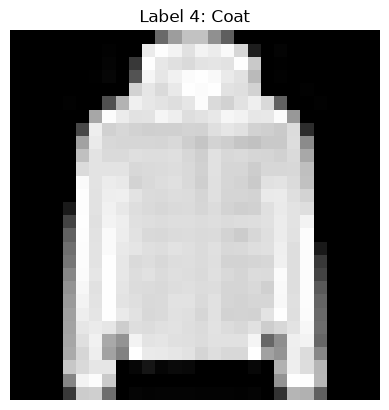

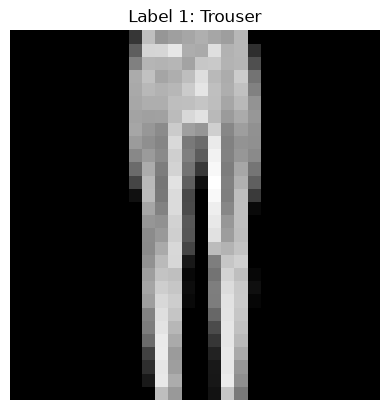

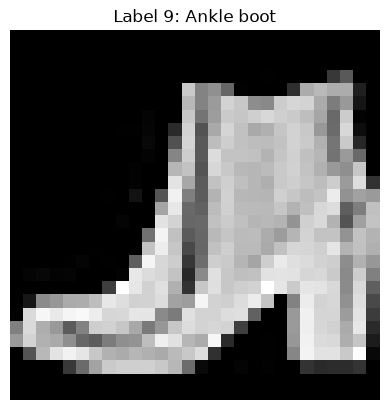

In [12]:
# Names corresponding to the 10 Fashion-MNIST numeric labels.
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


for _ in range(7):
    # Chooses one random index between 0 and the last training image.
    i = np.random.randint(0, len(x_train))

    # Displays the randomly selected image in grayscale.
    plt.imshow(x_train[i], cmap='gray')

    # Uses the numeric label to display the corresponding clothing name.
    plt.title(f"Label {y_train[i]}: {class_names[y_train[i]]}")

    # Hides the x/y axes because they are not useful for viewing the image.
    plt.axis('off')

    # Displays the image.
    plt.show()

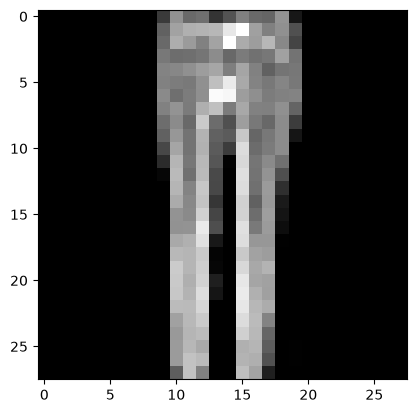

In [13]:
plt.imshow(x_train[11], cmap='gray')
plt.show()

In [14]:
x_train[11]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,  58, 145, 106, 111,
         52,  83, 127, 106, 101, 146,  23,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  97, 161, 175, 178,
        182, 230, 254, 159, 127, 143,  80,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 106, 172, 154, 128,
        163, 254, 170, 156, 182, 135,  68,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 120, 109, 111, 117,
        139, 104, 123, 113, 119, 160, 115,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 130, 134, 143, 156,
        165, 126, 164, 128,  98, 116, 119,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 128, 124, 122, 143,
        190, 234, 168, 130, 120, 132, 120,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [15]:
x_train[11].ravel()

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,  58, 145, 106, 111,
        52,  83, 127, 106, 101, 146,  23,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  97, 161,
       175, 178, 182, 230, 254, 159, 127, 143,  80,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
       106, 172, 154, 128, 163, 254, 170, 156, 182, 135,  68,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0, 120, 109, 111, 117, 139, 104, 123, 113, 119, 160, 115,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0, 130, 134, 143, 156, 165, 126, 164, 128,  98,
       116, 119,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0, 128, 124, 122, 143, 190, 234, 168,
       130, 120, 132, 120,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0, 137, 111, 124, 14

In [16]:
def build_model(activation: str = 'relu'):
    # Defines a function that creates and returns a neural network.
    #
    # activation: str = 'relu'
    # means that by default the hidden layers will use ReLU.
    # Later you could call:
    # build_model('sigmoid')
    # to test another activation function.


    model = Sequential([
        # Sequential means:
        # data passes through the layers one after another,
        # in exactly the order written below.


        Input(shape=(28, 28)),
        # Defines the shape of ONE input image.
        #
        # Fashion-MNIST image:
        # 28 pixels × 28 pixels.


        Flatten(),
        # Converts the 28 × 28 image into one vector.
        #
        # 28 × 28 = 784
        #
        # Before:
        # (28, 28)
        #
        # After:
        # (784,)
        #
        # This is essentially the same idea as:
        # x_train[11].ravel()


        Dense(64, activation=activation),
        # First hidden Dense layer.
        #
        # Receives the 784 pixel values.
        # Contains 64 neurons.
        # Each neuron is connected to ALL 784 inputs.
        #
        # activation is 'relu' by default.


        Dense(64, activation=activation),
        # Second hidden layer.
        #
        # Receives the 64 outputs from the previous layer.
        # Contains another 64 neurons.


        Dense(128, activation=activation),
        # Third hidden layer.
        #
        # Receives 128 values.
        # Produces 128 values.


        Dense(10, activation='softmax')
        # Output layer.
        #
        # Fashion-MNIST has 10 possible classes,
        # therefore we need 10 output neurons.
        #
        # softmax converts the 10 outputs into probabilities.
        #
        # Example:
        # [0.01, 0.02, 0.03, 0.80, ...]
        #
        # The largest probability becomes the predicted class.


        # These are experiments currently disabled with #:
        # , Dense(1, activation='linear')
        # , Dense(128, activation='relu')
        # , Dense(64, activation='softmax')
        # , ReLU()
    ])


    model.compile(
        optimizer=Adam(),
        # Adam determines HOW the network weights are changed
        # during training to reduce its errors.


        loss=SparseCategoricalCrossentropy(),
        # Loss measures HOW WRONG the model is.
        #
        # "Sparse" is appropriate because y_train contains
        # integer labels such as:
        #
        # 0, 1, 2, ... 9
        #
        # rather than one-hot encoded vectors.


        metrics=['accuracy']
        # Accuracy is the metric we want to observe.
        #
        # Example:
        # 0.87 = 87% of classifications were correct.
    )


    return model
    # Returns the completed model from the function.


model = build_model()
# Calls our function.
# Since we don't specify an activation,
# activation='relu' is used.


model.summary()
# Displays the architecture of the network,
# output shapes and number of trainable parameters.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,010 (250.04 KB)

 Trainable params: 64,010 (250.04 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.fit(
    x_train,
    # The 60,000 Fashion-MNIST training images.
    # Each image has shape (28, 28).


    y_train,
    # The correct label corresponding to each image.
    # Each label is an integer from 0 to 9.


    batch_size=512,
    # The model does NOT process all 60,000 images at once.
    #
    # It processes groups ("batches") of 1024 images.
    #
    # For each batch:
    # 1. make predictions
    # 2. calculate the loss
    # 3. calculate gradients
    # 4. Adam updates the model's weights


    epochs=50,
    # One epoch = the model has gone through the ENTIRE training dataset once.
    #
    # epochs=30 means:
    # the model sees the complete training dataset 30 times.

     #validation_split=0.2
     #Keeps 20% of x_train and y_train aside for validation.
     # So from the 60,000 original training images:

     validation_data=(x_val, y_val)
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5407 - loss: 7.0221 - val_accuracy: 0.6014 - val_loss: 5.9915
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6091 - loss: 5.5187 - val_accuracy: 0.6562 - val_loss: 4.2831
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6556 - loss: 3.3323 - val_accuracy: 0.6948 - val_loss: 2.3312
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7199 - loss: 2.1750 - val_accuracy: 0.7235 - val_loss: 2.1900
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7386 - loss: 2.0863 - val_accuracy: 0.7437 - val_loss: 2.1512
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7483 - loss: 2.0421 - val_accuracy: 0.7393 - val_loss: 2.1372
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7579 - loss: 2.0115 - val_accuracy: 0.7418 - val_loss: 2.1311
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7641 - loss: 1.9888 - val_accuracy: 0.7485 - val_loss:

In [18]:
model.history.history.keys()
# Shows which training results Keras stored after model.fit().

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

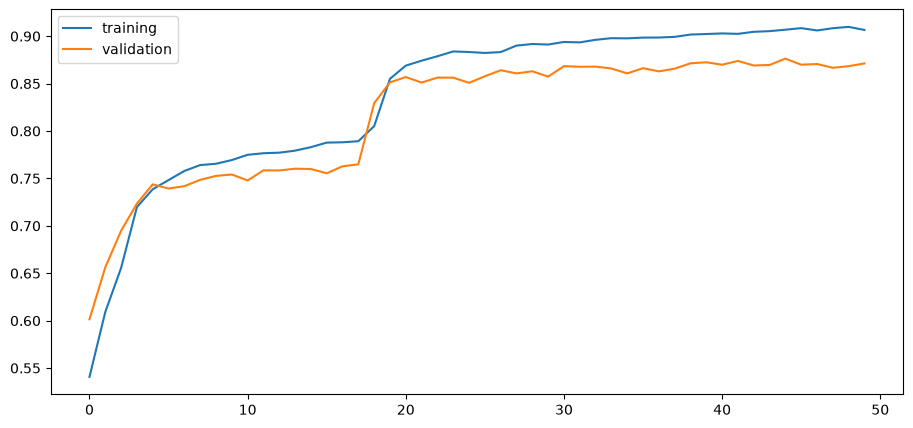

In [19]:
logs = model.history.history
# Retrieves the training history produced by model.fit().
#
# Because we used validation_split=0.2, logs contains:
# accuracy
# val_accuracy
# loss
# val_loss


plt.figure(figsize=(11, 5))
# Creates a new graph of size 11 × 5 inches.


plt.plot(logs['accuracy'], label='training')
# Plots training accuracy for every epoch.


plt.plot(logs['val_accuracy'], label='validation')
# Plots validation accuracy for every epoch.


plt.legend()
# Displays the labels "training" and "validation".


plt.show()
# Displays the graph.

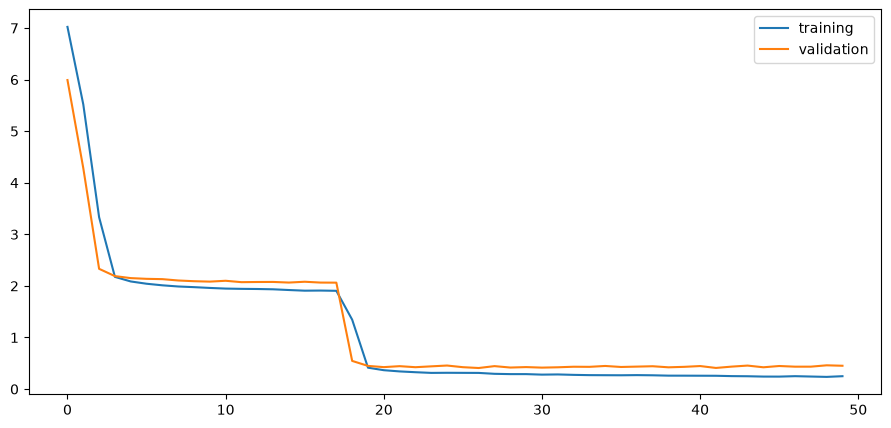

In [20]:
plt.figure(figsize=(11, 5))
# Creates a new separate graph.


plt.plot(logs['loss'], label='training')
# Training error for each epoch.


plt.plot(logs['val_loss'], label='validation')
# Validation error for each epoch.


plt.legend()
# Shows which line is which.


plt.show()
# Displays the graph.

In [21]:
y_pred_proba = model.predict(x_test)
y_pred =np.argmax(y_pred_proba, axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([9, 2, 1, ..., 8, 1, 5], shape=(10000,))

In [22]:
y_pred == y_test
(y_pred == y_test).sum()/y_test.shape[0]


np.float64(0.8644)

In [23]:
#print(classification_report(y_test, y_pred, target_names=class_names))
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.86      0.81      1000
           1       0.97      0.97      0.97      1000
           2       0.81      0.71      0.76      1000
           3       0.88      0.84      0.86      1000
           4       0.71      0.86      0.78      1000
           5       0.96      0.96      0.96      1000
           6       0.72      0.59      0.65      1000
           7       0.95      0.93      0.94      1000
           8       0.95      0.96      0.96      1000
           9       0.94      0.95      0.95      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



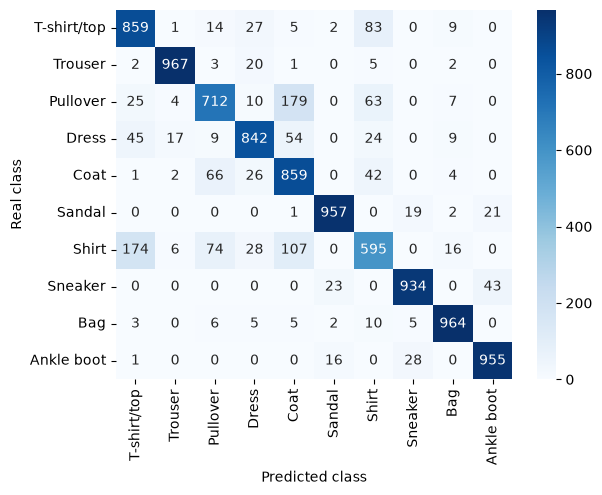

In [24]:
crosstab = confusion_matrix(y_test, y_pred)

sns.heatmap(crosstab, annot=True
            , fmt='d', cmap='Blues', xticklabels=class_names
            , yticklabels=class_names
            )

plt.xlabel("Predicted class")
plt.ylabel("Real class")
plt.show()

In [29]:
# We already created the confusion matrix:
# crosstab = confusion_matrix(y_test, y_pred)

print(
    f"{'Class':<15}"
    f"{'TP':>6}"
    f"{'FP':>6}"
    f"{'FN':>6}"
    f"{'Tot':>6}"
    f"{'TotMis':>6}"
)

print("-" * 45)


for i in range(len(class_names)):
    # True Positive:
    # real class = i AND predicted class = i
    tp = crosstab[i, i]


    # False Negative:
    # all real examples of class i
    # minus the ones correctly predicted.
    #
    # This corresponds to ROW i.
    fn = crosstab[i, :].sum() - tp


    # False Positive:
    # all examples predicted as class i
    # minus the ones that really belong to class i.
    #
    # This corresponds to COLUMN i.
    fp = crosstab[:, i].sum() - tp


    print(
        f"{class_names[i]:<15}"
        f"{tp:>6}"
        f"{fp:>6}"
        f"{fn:>6}"
        f"{tp + fn + fp:>6}"
        f"{fp + fn:>6}"
       
    )

Class              TP    FP    FN   TotTotMis
---------------------------------------------
T-shirt/top       859   251   141  1251   392
Trouser           967    30    33  1030    63
Pullover          712   172   288  1172   460
Dress             842   116   158  1116   274
Coat              859   352   141  1352   493
Sandal            957    43    43  1043    86
Shirt             595   227   405  1227   632
Sneaker           934    52    66  1052   118
Bag               964    49    36  1049    85
Ankle boot        955    64    45  1064   109


In [30]:
# Finds the positions where prediction and real label are different.
error_indices = np.where(y_pred != y_test)[0]


print("Number of errors:", len(error_indices))
print("Number of correct predictions:", len(y_test) - len(error_indices))

Number of errors: 1356
Number of correct predictions: 8644


In [31]:
# Class numbers from Fashion-MNIST:
# T-shirt/top = 0
# Shirt       = 6

real_class = 6
predicted_class = 0


pair_errors = np.where(
    (y_test == real_class) &
    (y_pred == predicted_class)
)[0]


print("Number of these errors:", len(pair_errors))


Number of these errors: 174


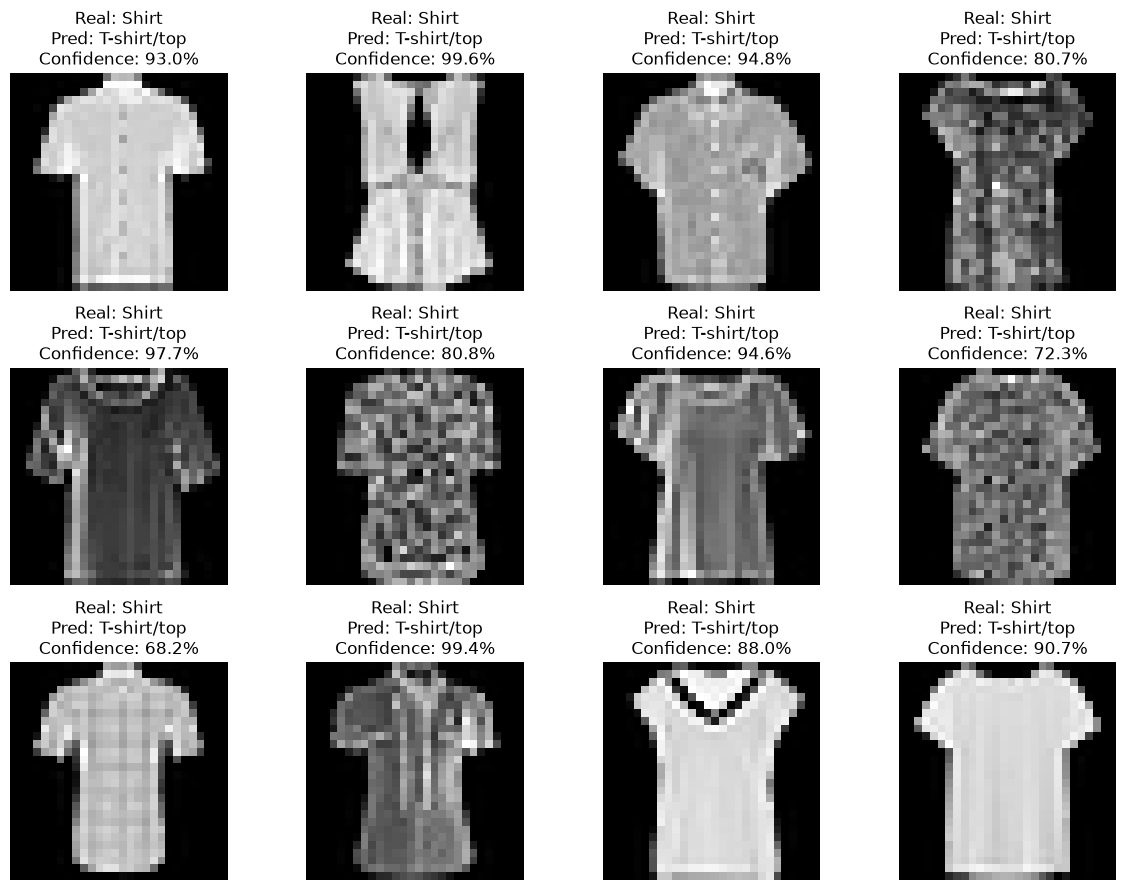

In [32]:
plt.figure(figsize=(12, 9))


for position, index in enumerate(pair_errors[:12]):

    plt.subplot(3, 4, position + 1)


    # Display the original Fashion-MNIST test image.
    plt.imshow(x_test[index], cmap='gray')


    # Probability assigned by the model
    # to the class it selected.
    confidence = y_pred_proba[index, y_pred[index]]


    plt.title(
        f"Real: {class_names[y_test[index]]}\n"
        f"Pred: {class_names[y_pred[index]]}\n"
        f"Confidence: {confidence:.1%}"
    )


    plt.axis('off')


plt.tight_layout()
plt.show()

In [34]:
# Class numbers from Fashion-MNIST:
# T-shirt/top = 4
# Shirt       = 2

real_class = 2
predicted_class = 4


pair_errors = np.where(
    (y_test == real_class) &
    (y_pred == predicted_class)
)[0]


print("Number of these errors:", len(pair_errors))


Number of these errors: 179


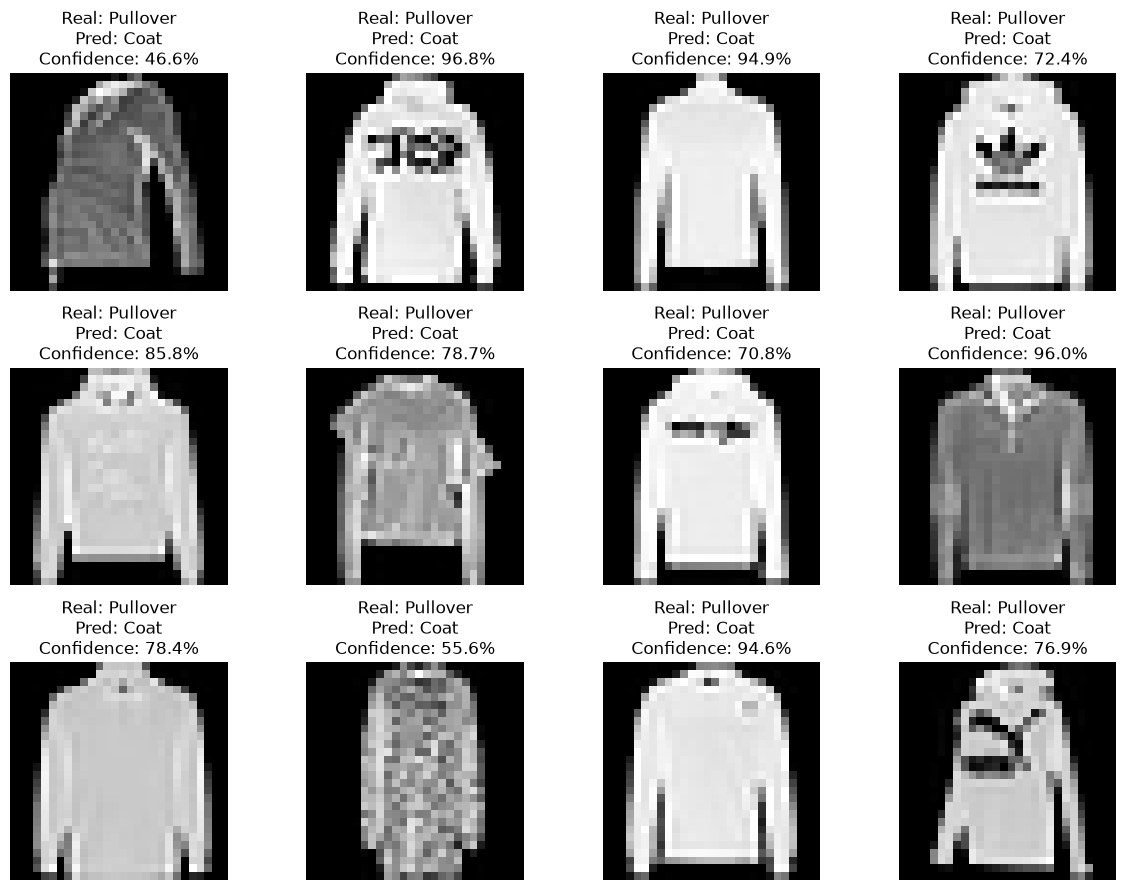

In [35]:
plt.figure(figsize=(12, 9))


for position, index in enumerate(pair_errors[:12]):

    plt.subplot(3, 4, position + 1)


    # Display the original Fashion-MNIST test image.
    plt.imshow(x_test[index], cmap='gray')


    # Probability assigned by the model
    # to the class it selected.
    confidence = y_pred_proba[index, y_pred[index]]


    plt.title(
        f"Real: {class_names[y_test[index]]}\n"
        f"Pred: {class_names[y_pred[index]]}\n"
        f"Confidence: {confidence:.1%}"
    )


    plt.axis('off')


plt.tight_layout()
plt.show()

In [36]:
y_pred_proba[index, y_pred[index]]

np.float32(0.7690493)

In [ ]:
# Confidence of the model's selected prediction
prediction_confidence = y_pred_proba[
    np.arange(len(y_pred)),
    y_pred
]


# Keep confidence only for wrongly classified images.
error_confidence = prediction_confidence[error_indices]


# Sort the errors from highest confidence to lowest confidence.
order = np.argsort(error_confidence)[::-1]


# Reorder the actual test-image indexes.
confident_errors = error_indices[order]



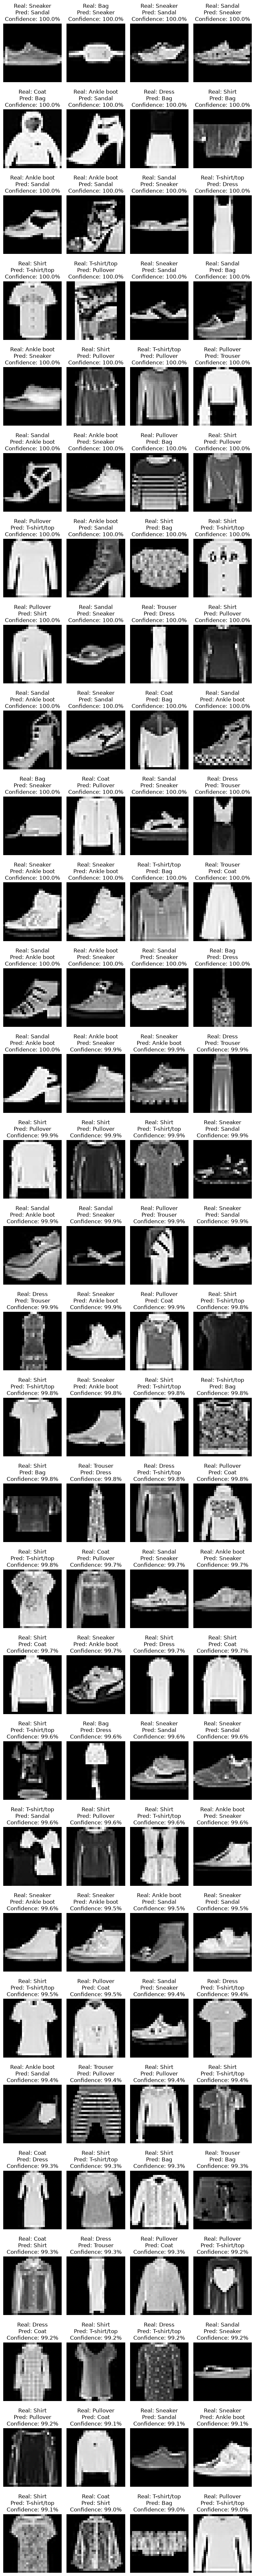

In [50]:
plt.figure(figsize=(8, 80))


for position, index in enumerate(confident_errors[:120]):

    plt.subplot(30, 4, position + 1)

    plt.imshow(x_test[index], cmap='gray')

    plt.title(
        f"Real: {class_names[y_test[index]]}\n"
        f"Pred: {class_names[y_pred[index]]}\n"
        f"Confidence: {prediction_confidence[index]:.1%}"
    )

    plt.axis('off')


plt.tight_layout()
plt.show()